In [6]:
# Import des paquets

import pandas as pd
import os
import load_data.donnees_chargement
from great_tables import GT


In [7]:
# Import des donnees

parite = load_data.donnees_chargement.load_parite()
parite.head()

/home/onyxia/work/Projet_python_2A/load_data/donnees_chargement.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  parite['week_day_number'] = parite['week_day'].replace({


,media_type,channel_code,channel_name,is_public_channel,date,week_day,school_holiday_zones,civil_holyday,hour,male_duration,female_duration,music_duration,week_day_number
636822,tv,ART,ARTE,True,2010-01-01,Friday,ABC,True,12,829.06,371.28,2056.80,5
636823,tv,ART,ARTE,True,2010-01-01,Friday,ABC,True,14,148.42,68.56,2993.40,5
636824,tv,ART,ARTE,True,2010-01-01,Friday,ABC,True,18,1722.84,307.90,1238.96,5
636825,tv,ART,ARTE,True,2010-01-01,Friday,ABC,True,21,2714.88,329.62,286.16,5
636826,tv,ART,ARTE,True,2010-01-02,Saturday,ABC,False,11,1254.78,1243.14,1070.86,6


In [8]:
# Calcul du temps de parole féminin et masculin par chaine

parite_chaine = parite.groupby('channel_code').agg(
    channel_name = ('channel_name', 'first'),
    female_duration = ('female_duration', 'sum'),
    male_duration = ('male_duration', 'sum')
).reset_index()

parite_chaine['proportion_female'] = parite_chaine['female_duration'] / (parite_chaine['female_duration'] + parite_chaine['male_duration'])

parite_chaine = parite_chaine.sort_values(by='proportion_female', ascending=False).reset_index()

In [9]:
# Affichage de la part de parole féminine par chaîne

(
    GT(parite_chaine[['channel_name', 'proportion_female']])
    .tab_header(
        title="Part du temps de parole féminin par chaîne",
        subtitle="De janvier 2010 à février 2019"
    )
    .fmt_percent(columns="proportion_female", decimals=0)
    .cols_label(
        channel_name = "Chaîne",
        proportion_female = "Part du temps de parole féminin"
    )
    .cols_width(cases={
        'channel_name': '70px',
        'proportion_female': '150px'
    })
    .tab_source_note("Source : INA")
)

GT(_tbl_data=  channel_name  proportion_female
0           M6           0.411471
1          TF1           0.364962
2     France 2           0.343634
3     France 3           0.318630
4         ARTE           0.291878, _body=<great_tables._gt_data.Body object at 0x7fdd7da44050>, _boxhead=Boxhead([ColInfo(var='channel_name', type=<ColInfoTypeEnum.default: 1>, column_label='Chaîne', column_align='left', column_width='70px'), ColInfo(var='proportion_female', type=<ColInfoTypeEnum.default: 1>, column_label='Part du temps de parole féminin', column_align='right', column_width='150px')]), _stub=<great_tables._gt_data.Stub object at 0x7fdd7db9bb60>, _spanners=Spanners([]), _heading=Heading(title='Part du temps de parole féminin par chaîne', subtitle='De janvier 2010 à février 2019', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fdd7da44440>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fdd7d9ecb90>, _source_notes=['Source : INA'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fdd7da44590>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fdd7da442f0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type='va

In [10]:
def parite_var_chaine(variable: str):
    parite_variable_chaine = parite.groupby(['channel_code', variable]).agg(
        channel_name = ('channel_name', 'first'),
        female_duration = ('female_duration', 'sum'),
        male_duration = ('male_duration', 'sum')
    ).reset_index()

    parite_variable_chaine['proportion_female'] = parite_variable_chaine['female_duration'] / (parite_variable_chaine['female_duration'] + parite_variable_chaine['male_duration'])

    return parite_variable_chaine

In [11]:
def diagramme_temps_parole_var(variable: str, code_chaine: str, label: str):
    parite_variable_chaine = parite_var_chaine(variable=variable)
    parite_variable = parite_variable_chaine[
        parite_variable_chaine['channel_code'] == code_chaine
    ].reset_index()
    diag = parite_variable.sort_values(by=variable).plot.bar(
        x = variable,
        y = 'proportion_female',
        title = "Temps de parole féminin par " + label + " pour la chaîne " + parite_variable['channel_name'][0],
        legend=False,
        xlabel=label,
        ylabel="Part de temps de parole féminin",
        grid=True
    )
    
    diag.xaxis.grid(False)

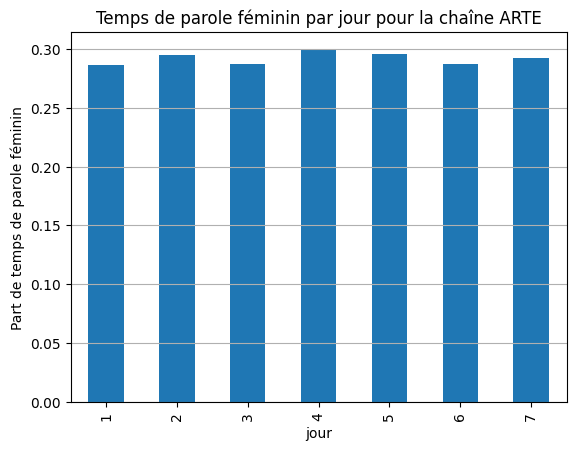

In [12]:
# Pour Arte : pas de différence entre les jours

diagramme_temps_parole_var(variable='week_day_number', code_chaine='ART', label='jour')

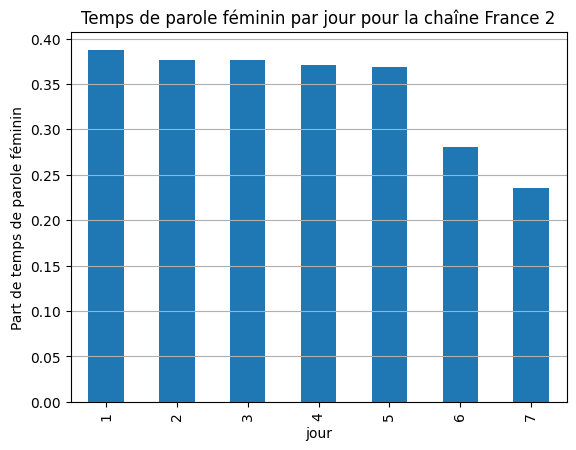

In [13]:
# Pour France 2 : décrochage de la part de parole féminine le week-end

diagramme_temps_parole_var(variable='week_day_number', code_chaine='FR2', label='jour')

In [14]:
# Evolution du temps de parole féminin

parite['monthly_date'] = parite['date'].dt.to_period('M')

parite_evolution_chaine = parite.groupby(['monthly_date', 'channel_code']).agg(
    male_duration = ('male_duration', 'sum'),
    female_duration = ('female_duration', 'sum'),
    channel_name = ('channel_name', 'first')
).reset_index()

parite_evolution_chaine['proportion_female'] = parite_evolution_chaine['female_duration'] / (parite_evolution_chaine['female_duration'] + parite_evolution_chaine['male_duration'])

In [15]:
# Representation de l'évolution du temps de parole féminin, par chaine

def diagramme_temps_parole_evolution(code_chaine):
    parite_evolution = parite_evolution_chaine[
        parite_evolution_chaine['channel_code'] == code_chaine
    ].reset_index()

    diag = parite_evolution.set_index('monthly_date')['proportion_female'].plot(
        title = "Temps de parole féminin par mois pour la chaîne " + parite_evolution['channel_name'][0],
        legend=False,
        xlabel="Mois",
        ylabel="Part de temps de parole féminin",
    )

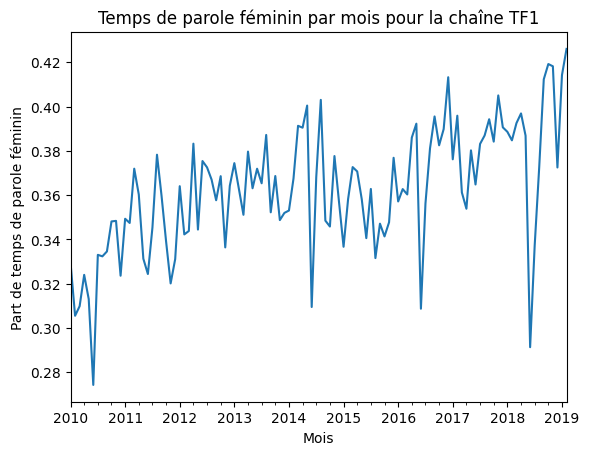

In [ ]:
# TF1 : de gros trous : Coupe du Monde et Euro de football ?
diagramme_temps_parole_evolution('TF1')


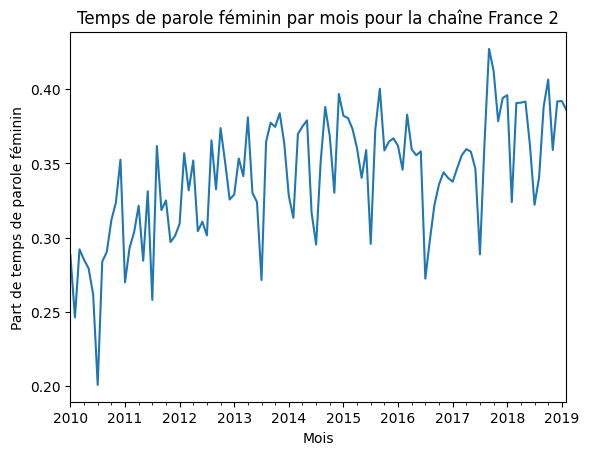

In [13]:
# France 2 : baisses récurrentes en été : Tour de France ?
diagramme_temps_parole_evolution('FR2')

In [14]:
# Création de la variable "mois de l'année"

parite['year_month_number'] = parite['date'].dt.month

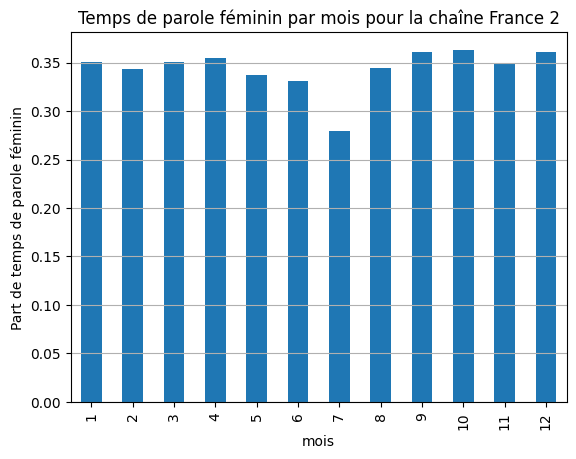

In [15]:
# France 2 : décrochage en juillet (Tour de France)
diagramme_temps_parole_var(variable='year_month_number', code_chaine='FR2', label='mois')

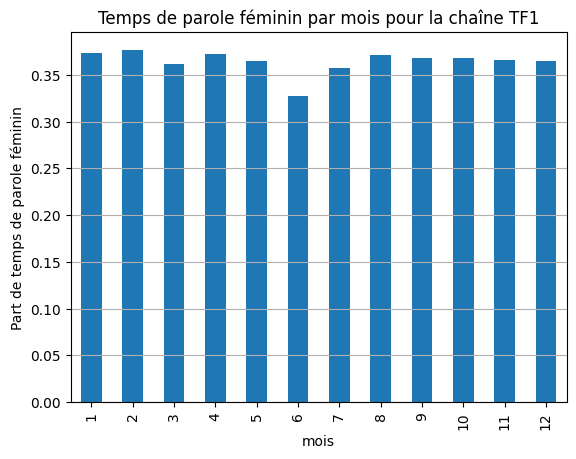

In [16]:
# TF1 : décrochage en juin (compétitions de football)
diagramme_temps_parole_var(variable='year_month_number', code_chaine='TF1', label='mois')

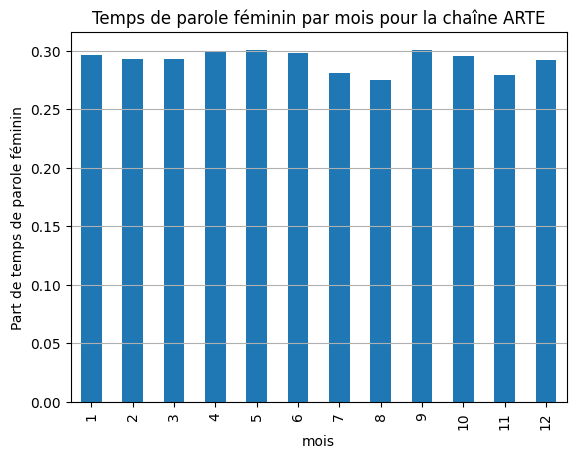

In [17]:
# ARTE : RAS
diagramme_temps_parole_var(variable='year_month_number', code_chaine='ART', label='mois')

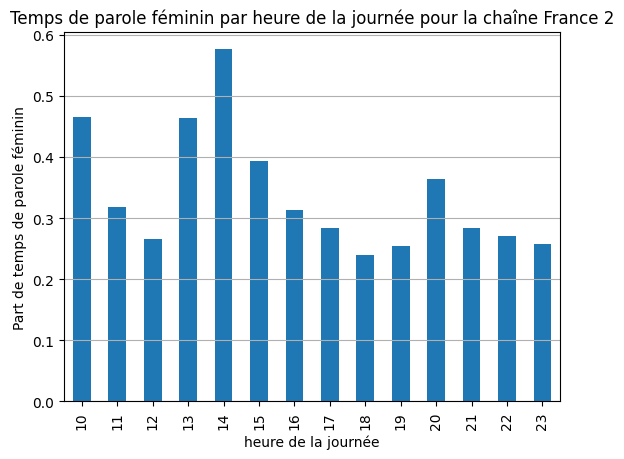

In [18]:
diagramme_temps_parole_var(variable='hour', code_chaine='FR2', label='heure de la journée')

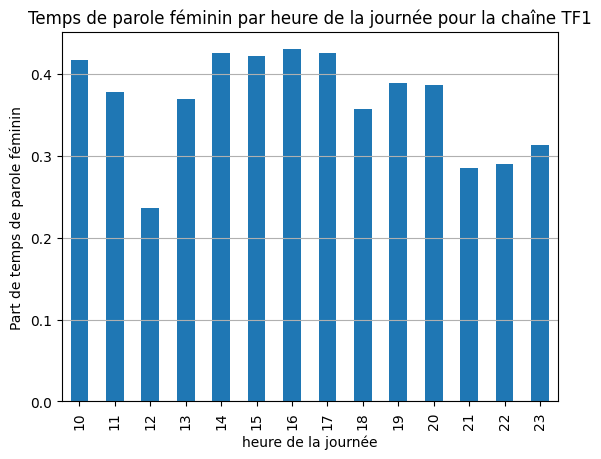

In [19]:
diagramme_temps_parole_var(variable='hour', code_chaine='TF1', label='heure de la journée')

In [ ]:
# import de sujets_jt

sujets_jt = load_data.donnees_chargement.load_sujet_tele()
sujets_jt.head()

/home/onyxia/work/Projet_python_2A/load_data/donnees_chargement.py:18: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  sujet_tele['Temps_total_JT'] = sujet_tele.groupby(['Date','Chaîne'])['Duree_sec'].transform(sum)


,Date,Chaîne,Thématique,Nb_sujets,Duree_sec,Temps_total_JT,Prop
0,2000-01-02,France 3,Catastrophes,2,235,1254,0.187400
1,2000-01-02,France 3,Culture-loisirs,1,138,1254,0.110048
2,2000-01-02,France 3,Environnement,3,306,1254,0.244019
3,2000-01-02,France 3,International,2,241,1254,0.192185
4,2000-01-02,France 3,Société,2,160,1254,0.127592


In [21]:
# Date en mois
sujets_jt['date_mois'] = sujets_jt['Date'].dt.to_period('M')

In [ ]:
sujets_jt_mois = sujets_jt.groupby(['date_mois', 'Thématique']).agg(
    Duree_sec = ('Duree_sec', 'sum'),
    Nb_sujets = ('Nb_sujets', 'sum'),
).reset_index()

temps_jt_mois = sujets_jt_mois.groupby(['date_mois']).agg(
    Duree_totale_jt = ('Duree_sec', 'sum')
).reset_index()

sujets_jt_mois = pd.merge(sujets_jt_mois, temps_jt_mois, on = 'date_mois')

sujets_jt_mois['prop'] = sujets_jt_mois['Duree_sec'] / (sujets_jt_mois['Duree_totale_jt'])

In [23]:
sujets_jt_mois_wide = pd.pivot(sujets_jt_mois, index='date_mois', columns='Thématique', values='prop')
sujets_jt_mois_wide.head()

Thématique,Catastrophes,Culture-loisirs,Economie,Education,Environnement,Faits divers,Histoire-hommages,International,Justice,Politique France,Santé,Sciences et techniques,Société,Sport
date_mois,,,,,,,,,,,,,,
2000-01,0.108687,0.114328,0.067390,0.037182,0.115947,0.021924,0.006574,0.114456,0.086589,0.030854,0.045743,0.010442,0.187303,0.052583
2000-02,0.026594,0.103851,0.063173,0.028605,0.072856,0.027205,0.008780,0.230690,0.076235,0.029697,0.065222,0.024556,0.181124,0.061411
2000-03,0.038203,0.104908,0.084879,0.043925,0.044642,0.019225,0.005483,0.158483,0.078693,0.116445,0.030358,0.013832,0.201742,0.059182
2000-04,0.022059,0.111646,0.102833,0.009457,0.057398,0.032685,0.020619,0.150724,0.042933,0.070225,0.044076,0.031934,0.192078,0.111335
2000-05,0.028904,0.137204,0.067457,0.012864,0.038578,0.027084,0.010897,0.195371,0.043650,0.082571,0.025744,0.015565,0.233843,0.080270


In [24]:
parite_evolution = parite_evolution_chaine.groupby('monthly_date').agg(
    male_duration = ('male_duration', 'sum'),
    female_duration = ('female_duration', 'sum')
).reset_index()

parite_evolution['proportion_female'] = parite_evolution['female_duration'] / (parite_evolution['female_duration'] + parite_evolution['male_duration'])

In [25]:
parite_sujets_jt_mois = pd.merge(parite_evolution, sujets_jt_mois_wide, left_on = 'monthly_date', right_on='date_mois')

parite_sujets_jt_mois.head()

,monthly_date,male_duration,female_duration,proportion_female,Catastrophes,Culture-loisirs,Economie,Education,Environnement,Faits divers,Histoire-hommages,International,Justice,Politique France,Santé,Sciences et techniques,Société,Sport
0,2010-01,1244517.38,599343.86,0.325048,0.227933,0.120845,0.064571,0.027751,0.036760,0.030649,0.031271,0.103493,0.043376,0.045275,0.039219,0.009388,0.176149,0.043320
1,2010-02,1175345.68,500421.08,0.298622,0.107907,0.144298,0.088833,0.036603,0.036815,0.037313,0.012277,0.093333,0.055694,0.059497,0.028677,0.016750,0.200158,0.081846
2,2010-03,1367000.48,607993.84,0.307846,0.116758,0.112702,0.087707,0.020815,0.045938,0.039728,0.020156,0.098200,0.068248,0.149439,0.037810,0.011821,0.142009,0.048667
3,2010-04,1312753.24,616137.14,0.319426,0.105970,0.130927,0.075268,0.028785,0.041563,0.039981,0.012211,0.099669,0.048946,0.020042,0.036349,0.013241,0.309676,0.037374
4,2010-05,1230482.32,576157.94,0.318911,0.033069,0.143289,0.110710,0.022894,0.092423,0.047089,0.014381,0.146418,0.051138,0.029405,0.037137,0.010505,0.171196,0.090346


In [ ]:
# Définition des variables

X = parite_sujets_jt_mois[[
    'Catastrophes', 
    'Economie', 
    'Faits divers', 
    'International', 
    'Sport', 
    'Culture-loisirs', 
    'Education', 
    'Environnement', 
    'Politique France', 
    'Histoire-hommages', 
    'Justice',
    'Santé',
    'Sciences et techniques',
    'Société']]
y = parite_sujets_jt_mois['proportion_female']


In [ ]:
import statsmodels.api as sm

In [55]:
# Modèle avec tous les thèmes comme variables explicatives

Xc = sm.add_constant(X)
mod = sm.OLS(y, Xc)
modfit = mod.fit()
print(modfit.summary())

                            OLS Regression Results                            
Dep. Variable:      proportion_female   R-squared:                       0.617
Model:                            OLS   Adj. R-squared:                  0.564
Method:                 Least Squares   F-statistic:                     11.77
Date:                Sat, 18 Apr 2026   Prob (F-statistic):           1.01e-14
Time:                        16:22:47   Log-Likelihood:                 322.78
No. Observations:                 109   AIC:                            -617.6
Df Residuals:                      95   BIC:                            -579.9
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

In [ ]:
# Variables significatives à 5 % uniquement

Xsign = parite_sujets_jt_mois[[
    'Economie', 
    'Sport', 
    'Culture-loisirs', 
    'Histoire-hommages', 
    'Sciences et techniques']]

In [ ]:
Xsignc = sm.add_constant(Xsign)
mod2 = sm.OLS(y, Xsignc)
mod2fit = mod2.fit()
print(mod2fit.summary())

                            OLS Regression Results                            
Dep. Variable:      proportion_female   R-squared:                       0.575
Model:                            OLS   Adj. R-squared:                  0.554
Method:                 Least Squares   F-statistic:                     27.83
Date:                Sat, 18 Apr 2026   Prob (F-statistic):           9.76e-18
Time:                        16:23:03   Log-Likelihood:                 317.07
No. Observations:                 109   AIC:                            -622.1
Df Residuals:                     103   BIC:                            -606.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

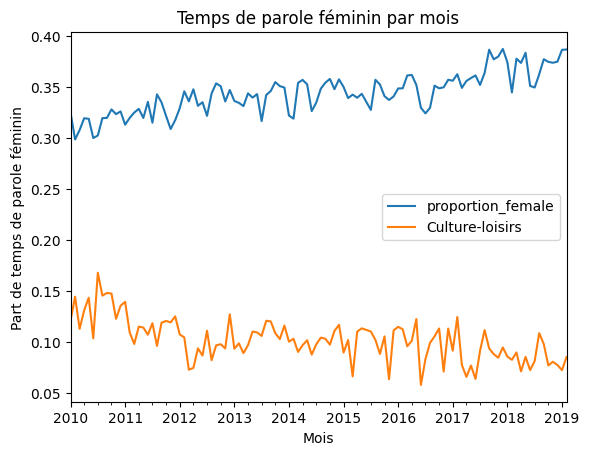

In [ ]:
diag = parite_sujets_jt_mois.set_index('monthly_date')[['proportion_female', 'Culture-loisirs']].plot(
    title = "Temps de parole féminin par mois",
    legend=True,
    xlabel="Mois",
    ylabel="Part de temps de parole féminin",
)
# On voit que l'évolution temporelle explique la grande corrélatio entre les deux variables

In [77]:
# Trouver la tendance de la part de parole féminine

parite_sujets_jt_mois = parite_sujets_jt_mois.reset_index()

T = parite_sujets_jt_mois['index']

Tc = sm.add_constant(T)
modT = sm.OLS(y, Tc)
modTfit = modT.fit()

# Extract coefficients
coeffs = modTfit.params
cons = coeffs[0]
trend = coeffs[1]
trend

/tmp/ipykernel_29717/616446811.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cons = coeffs[0]
/tmp/ipykernel_29717/616446811.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  trend = coeffs[1]


np.float64(0.0005213797509534367)

In [81]:
parite_sujets_jt_mois['proportion_female_detrend'] = (
    parite_sujets_jt_mois['proportion_female'] - cons - trend * parite_sujets_jt_mois['index']
)

y_detrend = parite_sujets_jt_mois['proportion_female_detrend']

In [85]:
mod_detrend = sm.OLS(y_detrend, Xsignc)
mod_detrendfit = mod_detrend.fit()
print(mod_detrendfit.summary())


                                OLS Regression Results                               
Dep. Variable:     proportion_female_detrend   R-squared:                       0.274
Model:                                   OLS   Adj. R-squared:                  0.239
Method:                        Least Squares   F-statistic:                     7.772
Date:                       Sat, 18 Apr 2026   Prob (F-statistic):           3.08e-06
Time:                               16:48:44   Log-Likelihood:                 346.32
No. Observations:                        109   AIC:                            -680.6
Df Residuals:                            103   BIC:                            -664.5
Df Model:                                  5                                         
Covariance Type:                   nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

In [86]:
sportc = sm.add_constant(parite_sujets_jt_mois['Sport'])

mod_sport = sm.OLS(y_detrend, sportc)
mod_sportfit = mod_sport.fit()
print(mod_sportfit.summary())


                                OLS Regression Results                               
Dep. Variable:     proportion_female_detrend   R-squared:                       0.242
Model:                                   OLS   Adj. R-squared:                  0.235
Method:                        Least Squares   F-statistic:                     34.20
Date:                       Sat, 18 Apr 2026   Prob (F-statistic):           5.47e-08
Time:                               16:51:33   Log-Likelihood:                 343.99
No. Observations:                        109   AIC:                            -684.0
Df Residuals:                            107   BIC:                            -678.6
Df Model:                                  1                                         
Covariance Type:                   nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

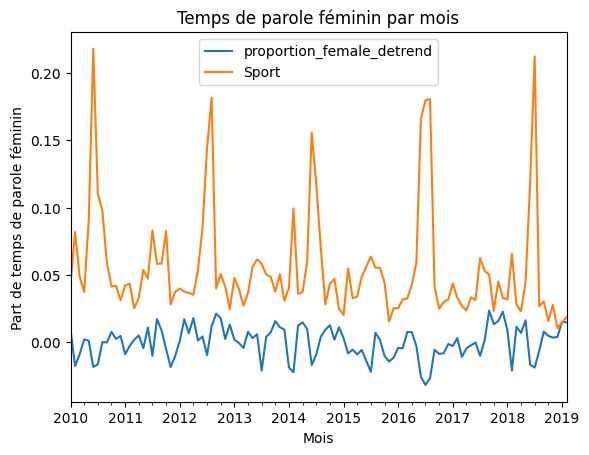

In [87]:
diag = parite_sujets_jt_mois.set_index('monthly_date')[['proportion_female_detrend', 'Sport']].plot(
    title = "Temps de parole féminin par mois",
    legend=True,
    xlabel="Mois",
    ylabel="Part de temps de parole féminin",
)